In [4]:
import sys
!{sys.executable} -m pip install -r requirements.txt

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [6]:
df = pd.read_csv("../notebook/regions_enriched2.csv")
df.head()

,Region,Country,Crop,Latitude,Longitude,Year,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm
0,İstanbul,Türkiye,Wheat,41.2506,29.5094,2023,16.182630,17.175781,15.232110,80.475014,2.049370,4.770137,14.233616,16.692226,16.692169,0.288007,0.286300
1,İstanbul,Türkiye,Barley,41.3800,29.1721,2023,16.182630,17.175781,15.232110,80.475014,2.049370,4.770137,14.233616,16.695959,16.696233,0.285911,0.285165
2,İstanbul,Türkiye,Maize (corn),40.8898,29.9670,2023,14.773178,19.958959,10.612384,78.871096,2.715726,2.276274,14.410082,15.832728,15.811747,0.284012,0.272278
3,İstanbul,Türkiye,Apples,40.3204,29.8792,2023,13.452274,19.634384,8.574356,75.705288,2.244384,1.428493,14.410082,14.027728,13.990776,0.268820,0.254041
4,İstanbul,Türkiye,Olives,40.7145,29.8818,2023,13.452274,19.634384,8.574356,75.705288,2.244384,1.428493,14.410082,16.735788,16.711438,0.315766,0.312187


In [19]:
df.tail()

,Region,Country,Crop,Latitude,Longitude,Year,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm
805,Kilis,Türkiye,Hazelnuts,38.0578,40.5985,2023-01-01,17.559288,25.212986,10.818795,52.884137,1.557151,0.927589,16.992027,14.123849,14.038154,0.284052,0.294474
806,Kilis,Türkiye,Watermelons,37.5693,40.3530,2023-01-01,16.628575,23.838932,10.215671,53.047616,1.245123,1.312849,17.620767,14.748864,14.542050,0.230869,0.229806
807,Kilis,Türkiye,Walnuts,37.2355,39.9190,2023-01-01,19.427397,26.622411,12.924027,49.795863,1.270137,2.245836,17.790521,20.150802,20.164692,0.240048,0.246727
808,Kilis,Türkiye,Chick peas,37.7680,40.7192,2023-01-01,17.559288,25.212986,10.818795,52.884137,1.557151,0.927589,17.620767,14.413665,14.458449,0.277640,0.280977
809,Kilis,Türkiye,Lentils,37.5417,40.1882,2023-01-01,16.761616,23.670493,10.524356,52.963233,1.339973,2.333589,17.620767,15.745404,15.598399,0.240734,0.244125


In [8]:
df.dtypes

Region                            str
Country                           str
Crop                              str
Latitude                      float64
Longitude                     float64
Year                            int64
T2M                           float64
T2M_MAX                       float64
T2M_MIN                       float64
RH2M                          float64
PRECTOTCORR                   float64
WS2M                          float64
ALLSKY_SFC_SW_DWN             float64
soil_temperature_0_to_7cm     float64
soil_temperature_7_to_28cm    float64
soil_moisture_0_to_7cm        float64
soil_moisture_7_to_28cm       float64
dtype: object

In [20]:
df.shape

(810, 17)

In [9]:
df.columns

Index(['Region', 'Country', 'Crop', 'Latitude', 'Longitude', 'Year', 'T2M',
       'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M',
       'ALLSKY_SFC_SW_DWN', 'soil_temperature_0_to_7cm',
       'soil_temperature_7_to_28cm', 'soil_moisture_0_to_7cm',
       'soil_moisture_7_to_28cm'],
      dtype='str')

In [10]:
df.describe()

,Latitude,Longitude,Year,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm
count,810.000000,810.000000,810.0,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000
mean,39.275102,35.630786,2023.0,14.367823,19.826179,9.616926,67.131900,1.809105,2.319993,15.998678,15.138642,15.117632,0.271659,0.271813
std,1.456420,4.855853,0.0,3.673288,3.709062,4.486140,8.975857,0.633775,0.828037,1.465105,3.512796,3.476609,0.045746,0.044766
min,36.303500,26.818200,2023.0,6.006438,12.173096,0.432767,47.269342,1.000137,0.920301,13.750712,6.519886,6.459635,0.038630,0.070481
25%,38.308525,32.518225,2023.0,12.527562,17.474740,6.536110,60.984829,1.339973,1.872082,14.233616,12.008676,11.890208,0.237288,0.240825
50%,39.152750,36.835400,2023.0,14.470000,19.465370,10.215671,65.234863,1.760027,2.245836,16.477863,14.951084,14.844384,0.282683,0.282956
75%,40.627375,40.307025,2023.0,16.697699,23.090849,13.152877,76.664986,2.111342,2.514603,16.977644,17.234600,17.229184,0.299302,0.297062
max,41.699500,42.695300,2023.0,21.982904,27.455342,20.744685,81.772521,3.791973,4.818849,18.634055,24.355126,24.354943,0.389328,0.405137


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,810.0,39.275102,1.456420,36.303500,38.308525,39.152750,40.627375,41.699500
Longitude,810.0,35.630786,4.855853,26.818200,32.518225,36.835400,40.307025,42.695300
Year,810.0,2023.000000,0.000000,2023.000000,2023.000000,2023.000000,2023.000000,2023.000000
T2M,810.0,14.367823,3.673288,6.006438,12.527562,14.470000,16.697699,21.982904
T2M_MAX,810.0,19.826179,3.709062,12.173096,17.474740,19.465370,23.090849,27.455342
T2M_MIN,810.0,9.616926,4.486140,0.432767,6.536110,10.215671,13.152877,20.744685
RH2M,810.0,67.131900,8.975857,47.269342,60.984829,65.234863,76.664986,81.772521
PRECTOTCORR,810.0,1.809105,0.633775,1.000137,1.339973,1.760027,2.111342,3.791973
WS2M,810.0,2.319993,0.828037,0.920301,1.872082,2.245836,2.514603,4.818849
ALLSKY_SFC_SW_DWN,810.0,15.998678,1.465105,13.750712,14.233616,16.477863,16.977644,18.634055


In [ ]:
#df["Year"] = pd.to_datetime(df["Year"], format='%Y')

In [14]:
df["Year"].dtype

dtype('<M8[us]')

In [12]:
df.isnull().sum()

Region                        0
Country                       0
Crop                          0
Latitude                      0
Longitude                     0
Year                          0
T2M                           0
T2M_MAX                       0
T2M_MIN                       0
RH2M                          0
PRECTOTCORR                   0
WS2M                          0
ALLSKY_SFC_SW_DWN             0
soil_temperature_0_to_7cm     0
soil_temperature_7_to_28cm    0
soil_moisture_0_to_7cm        0
soil_moisture_7_to_28cm       0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
805    False
806    False
807    False
808    False
809    False
Length: 810, dtype: bool

In [16]:
df.dtypes

Region                                   str
Country                                  str
Crop                                     str
Latitude                             float64
Longitude                            float64
Year                          datetime64[us]
T2M                                  float64
T2M_MAX                              float64
T2M_MIN                              float64
RH2M                                 float64
PRECTOTCORR                          float64
WS2M                                 float64
ALLSKY_SFC_SW_DWN                    float64
soil_temperature_0_to_7cm            float64
soil_temperature_7_to_28cm           float64
soil_moisture_0_to_7cm               float64
soil_moisture_7_to_28cm              float64
dtype: object

In [23]:
import sys
!{sys.executable} -m pip install pyarrow

   ---------------------------------------- 0.0/27.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.5 MB ? eta -:--:--
    --------------------------------------- 0.5/27.5 MB 5.1 MB/s eta 0:00:06
   --- ------------------------------------ 2.4/27.5 MB 8.5 MB/s eta 0:00:03
   ------ --------------------------------- 4.7/27.5 MB 9.4 MB/s eta 0:00:03
   --------- ------------------------------ 6.6/27.5 MB 9.1 MB/s eta 0:00:03
   ----------- ---------------------------- 8.1/27.5 MB 8.7 MB/s eta 0:00:03
   --------------- ------------------------ 10.5/27.5 MB 9.1 MB/s eta 0:00:02
   ----------------- ---------------------- 12.1/27.5 MB 9.3 MB/s eta 0:00:02
   -------------------- ------------------- 14.4/27.5 MB 9.2 MB/s eta 0:00:02
   ----------------------- ---------------- 16.5/27.5 MB 9.3 MB/s eta 0:00:02
   ------------------------- -------------- 17.8/27.5 MB 9.1 MB/s eta 0:00:02
   ---------------------------- ----------- 19.7/27.5 MB 9.0 MB/s eta 0:00:01
   ----

In [45]:
numerical_cols = df.select_dtypes(include="float")
categorical_cols = df.select_dtypes(include="str")

In [36]:
numerical_data.dtypes

Latitude                      float64
Longitude                     float64
T2M                           float64
T2M_MAX                       float64
T2M_MIN                       float64
RH2M                          float64
PRECTOTCORR                   float64
WS2M                          float64
ALLSKY_SFC_SW_DWN             float64
soil_temperature_0_to_7cm     float64
soil_temperature_7_to_28cm    float64
soil_moisture_0_to_7cm        float64
soil_moisture_7_to_28cm       float64
dtype: object

In [37]:
categorical_data.dtypes

Region     str
Country    str
Crop       str
dtype: object

In [38]:
corelation = df.corr(numeric_only="True")
corelation

,Latitude,Longitude,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm
Latitude,1.000000,-0.136100,-0.348830,-0.646621,-0.053128,0.855904,0.699726,0.237333,-0.940918,-0.321820,-0.318528,0.446604,0.375727
Longitude,-0.136100,1.000000,-0.369722,-0.311882,-0.362258,-0.289866,0.023303,-0.280900,0.162777,-0.337102,-0.330569,0.199983,0.178690
T2M,-0.348830,-0.369722,1.000000,0.855707,0.927218,-0.207055,-0.163642,0.201906,0.213736,0.857569,0.851954,-0.234729,-0.174310
T2M_MAX,-0.646621,-0.311882,0.855707,1.000000,0.601538,-0.571405,-0.415796,-0.188289,0.519142,0.714205,0.705203,-0.350842,-0.280064
T2M_MIN,-0.053128,-0.362258,0.927218,0.601538,1.000000,0.115886,0.070666,0.426903,-0.071901,0.809408,0.807084,-0.091630,-0.051013
RH2M,0.855904,-0.289866,-0.207055,-0.571405,0.115886,1.000000,0.771432,0.363596,-0.879212,-0.153770,-0.148248,0.465857,0.420224
PRECTOTCORR,0.699726,0.023303,-0.163642,-0.415796,0.070666,0.771432,1.000000,-0.045912,-0.782370,-0.167367,-0.162565,0.630374,0.610026
WS2M,0.237333,-0.280900,0.201906,-0.188289,0.426903,0.363596,-0.045912,1.000000,-0.160391,0.242850,0.249394,-0.107439,-0.106207
ALLSKY_SFC_SW_DWN,-0.940918,0.162777,0.213736,0.519142,-0.071901,-0.879212,-0.782370,-0.160391,1.000000,0.216141,0.213951,-0.535074,-0.468868
soil_temperature_0_to_7cm,-0.321820,-0.337102,0.857569,0.714205,0.809408,-0.153770,-0.167367,0.242850,0.216141,1.000000,0.999633,-0.268109,-0.236070


<Axes: >

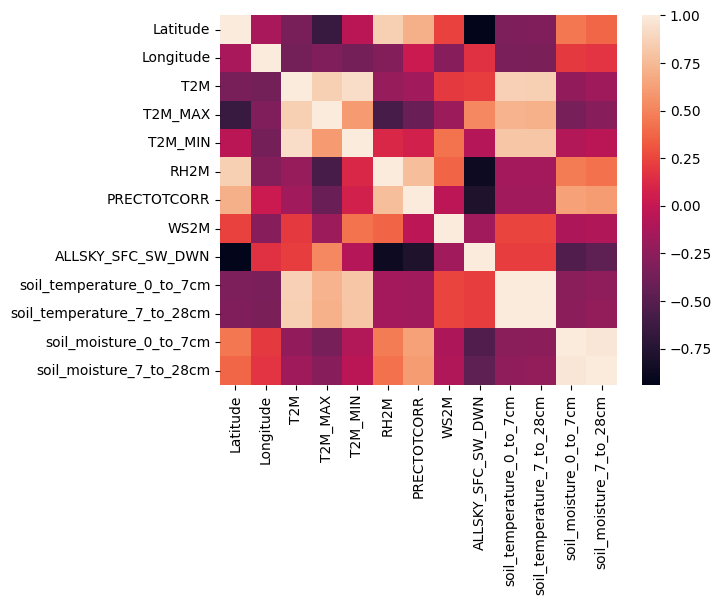

In [39]:
sns.heatmap(corelation)

In [40]:
na = df.isna().sum().sort_values(ascending=False)
na = na[na > 0]
display(na.head(20))
if len(na) > 0:
    plt.figure(figsize=(12, 5))
    sns.barplot(x=na.index, y=na.values, color="tomato")
    plt.xticks(rotation=60, ha="right")
    plt.title("Eksik Değer Sayıları")
    plt.ylabel("Adet")
    plt.show()

Series([], dtype: int64)

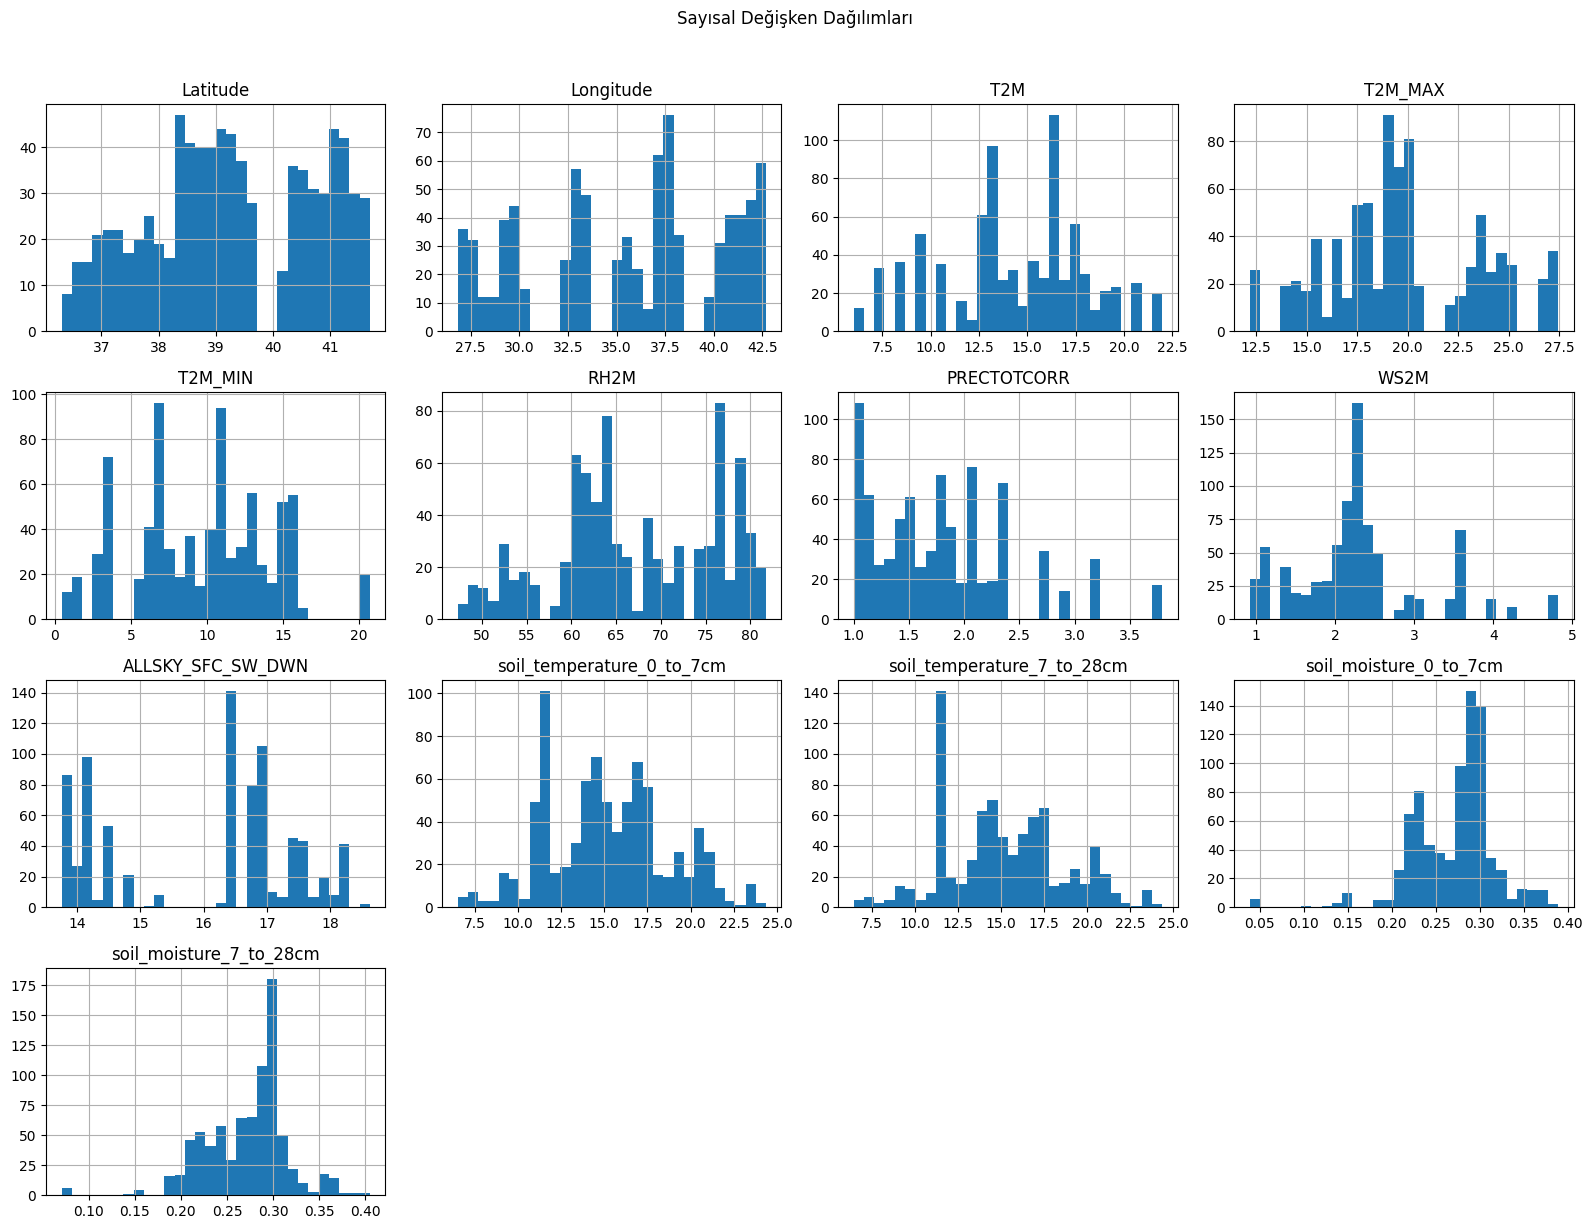

In [44]:
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
df[num_cols].hist(bins=30, figsize=(16, 12))
plt.suptitle("Sayısal Değişken Dağılımları", y=1.02)
plt.tight_layout()
plt.show()

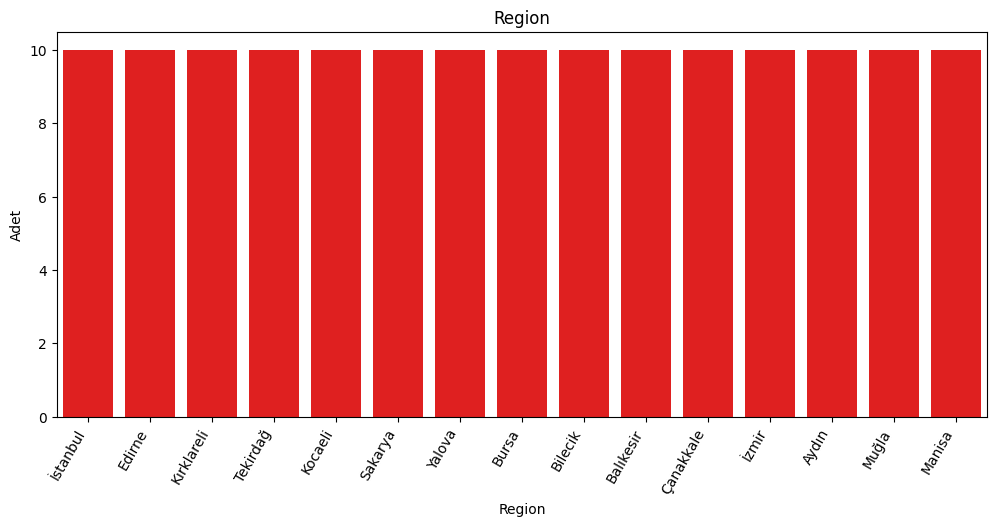

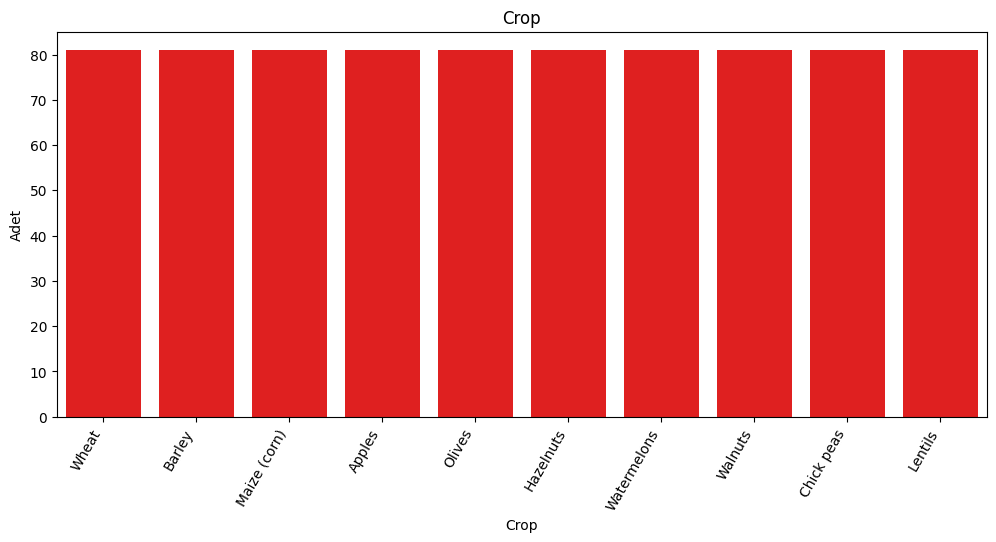

In [46]:
for col in ["Region", "Crop"]:
    topn = df[col].value_counts().head(15)
    plt.figure(figsize=(12,5))
    sns.barplot(x=topn.index, y=topn.values, color="red")
    plt.xticks(rotation = 60, ha = "right")
    plt.title(f"{col}")
    plt.ylabel("Adet")
    plt.show()

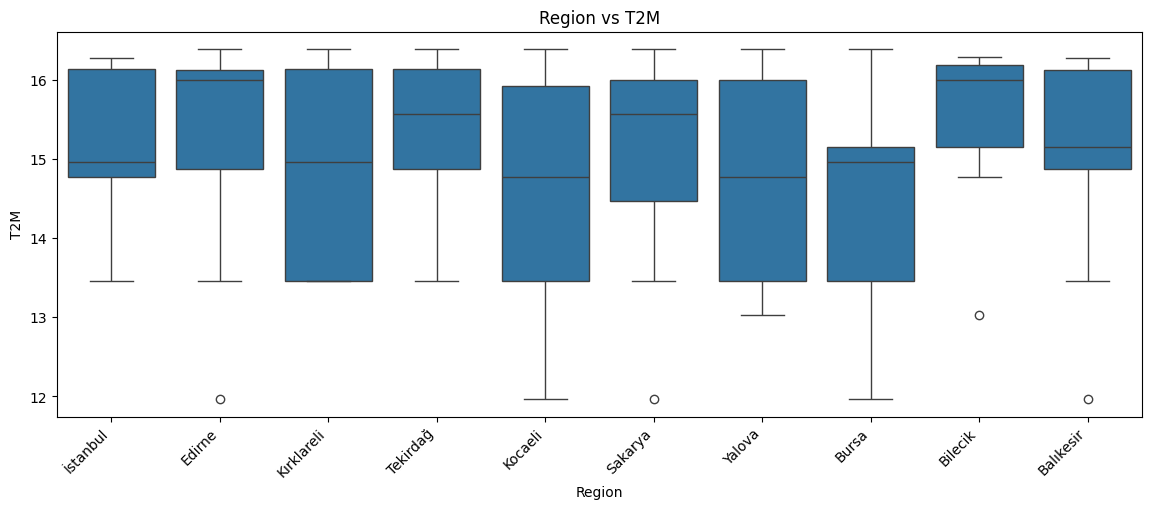

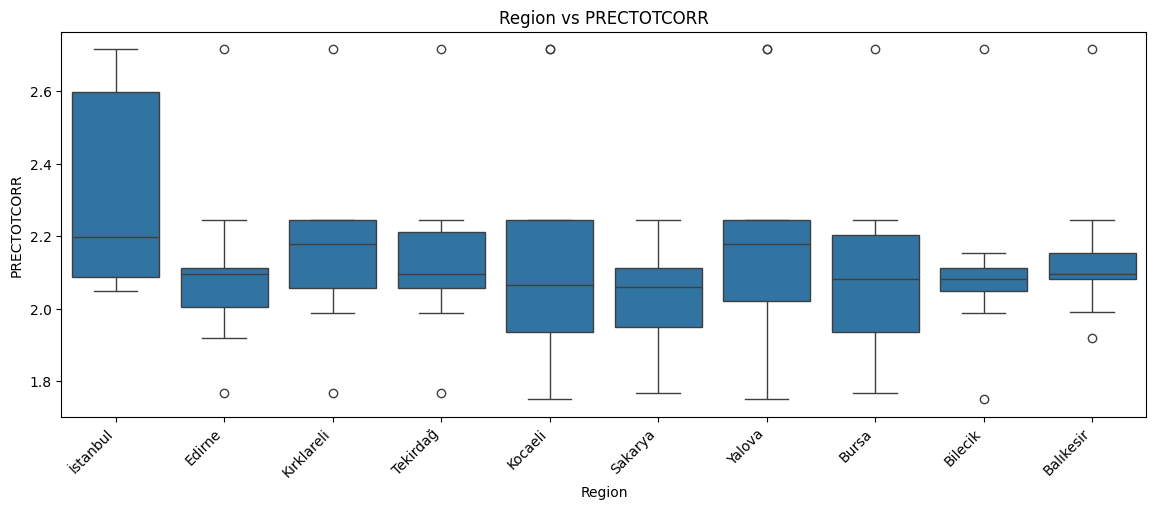

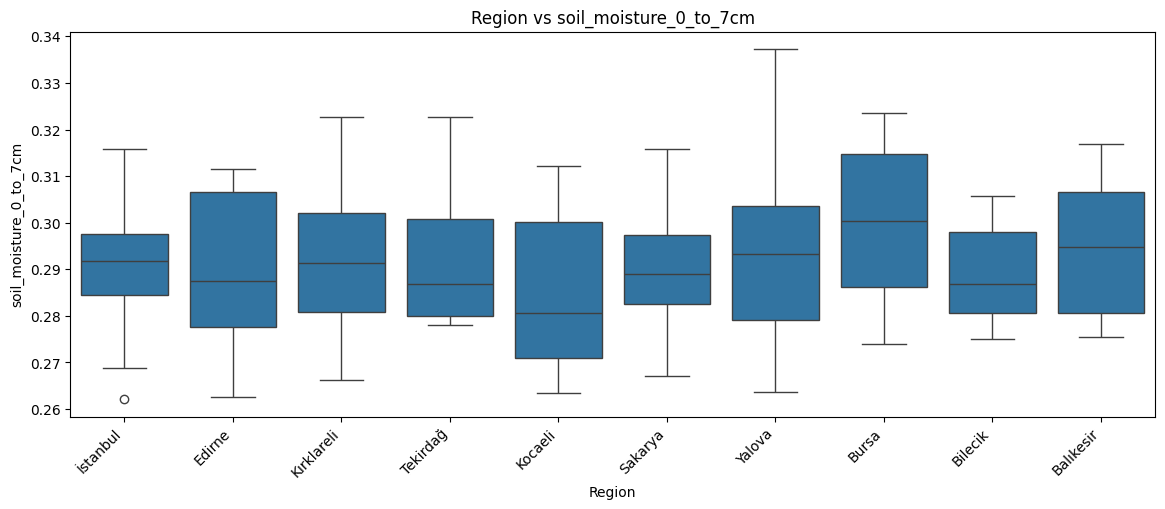

In [47]:
for col in ["T2M", "PRECTOTCORR", "soil_moisture_0_to_7cm"]:
    plt.figure(figsize=(14, 5))
    top_regions = df["Region"].value_counts().head(10).index
    sns.boxplot(data=df[df["Region"].isin(top_regions)], x="Region", y=col)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Region vs {col}")
    plt.show()

In [48]:
q1 = df[num_cols].quantile(0.25)
q3 = df[num_cols].quantile(0.75)
iqr = q3 - q1
outlier_ratio = (((df[num_cols] < (q1 - 1.5*iqr)) | (df[num_cols] > (q3 + 1.5*iqr))).sum() / len(df)).sort_values(ascending=False)
display(outlier_ratio.head(15))

WS2M                          0.153086
PRECTOTCORR                   0.020988
T2M                           0.014815
soil_moisture_7_to_28cm       0.013580
soil_moisture_0_to_7cm        0.013580
T2M_MIN                       0.000000
T2M_MAX                       0.000000
Longitude                     0.000000
Latitude                      0.000000
ALLSKY_SFC_SW_DWN             0.000000
RH2M                          0.000000
soil_temperature_7_to_28cm    0.000000
soil_temperature_0_to_7cm     0.000000
dtype: float64

In [50]:
!pip install fastparquet

   ---------------------------------------- 0.0/667.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/667.5 kB ? eta -:--:--
   ---------------------------------------- 667.5/667.5 kB 2.4 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 528.0 kB/s eta 0:00:03
   ------------ --------------------------- 0.5/1.7 MB 528.0 kB/s eta 0:00:03
   ------------------ --------------------- 0.8/1.7 MB 496.8 kB/s eta 0:00:02
   ------------------ --------------------- 0.8/1.7 MB 496.8 kB/s eta 0:00:02
   ------------------ --------------------- 0.8/1.7 MB 496.8 kB/s eta 0:00:02
   ------------------------ --------------- 1.

In [51]:
# Tüm analizini ve veri tipi dönüşümlerini yaptığın son halini kaydet
df.to_parquet('regions_final_checkpoint.parquet', engine='fastparquet')
print("İşlem tamam! Veri 'regions_final_checkpoint.parquet' olarak kaydedildi.")

İşlem tamam! Veri 'regions_final_checkpoint.parquet' olarak kaydedildi.


In [52]:
import pickle

with open('regions_checkpoint.pkl', 'wb') as f:
    pickle.dump(df, f)
print("Veri Pickle formatında başarıyla kaydedildi!")

Veri Pickle formatında başarıyla kaydedildi!


### Extra

<!-- import pandas as pd
import pickle

with open('regions_checkpoint.pkl', 'rb') as f:
    df = pickle.load(f) -->